# Fitting molecular energy constants

Energies of states are approximated by using polynomials, with fitted coefficients. These coefficients are historically fitted from experimental spectroscopic data. When one uses these coefficients from literature, it is important to consider the amount of transitions that were fitted, and the order of the fitted polynomial.

A common mistake of spectroscopists is using coefficients from multiple sources, or using coefficients for transitions that they were not determined for.

In this file, we demonstrate how to use a simple fitting algorithm to determine ones own coefficients using HITRAN data, which has a high amount of transitions.


# Theory

Different molecules have different formulations for their energy levels.

| Molecule | Polynomial                                                               |
| -------- | ------------------------------------------------------------------------ |
| H2       | $\Sigma_i c_i \left( J \cdot (J + 1) \right)^n$                          |
| NO       | $\Sigma_i c_i \left( (J-\frac{1}{2} ) \cdot (J + \frac{3}{2}) \right)^n$ |


# Methods

We use the HITRAN database as a map from the quantum numbers of state $i$ to the energy $E_i$ of state $i$, i.e. $\left| i \right \rangle \equiv \{J_i, v_i, ...\}\ \rightarrow\ E_i$.
In the case of e.g. H2, the set of quantum numbers $\{J_i,\ v_i\}$ completely defines the state $\left| i \right \rangle$. We define the set of quantum numbers as $\{q_{j}\}_i$

We're then solving the matrix equation of the form $Ax=b$ for $x$, or

$$
\begin{pmatrix}
f_1(q_1) & f_2(q_1) & \dots & f_n(q_1) \\
f_1(q_2) & f_2(q_2) & \dots & f_n(q_2) \\
\dots \\
f_1(q_3) & f_2(q_3) & \dots & f_n(q_3)
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
\dots \\
c_n
\end{pmatrix}
=
\begin{pmatrix}
E_1 \\
E_2 \\
\dots \\
E_n
\end{pmatrix}
$$


Loaded 737 transitions from HITRAN
	Discarding 0 transitions with high energy states
	Discarding 524 with no (exact) matches
Transitions[737](molec_id, trans_id, vacuum_wavenumber, a, statep, statepp, final_degeneracy, initial_degeneracy, sw, initial_E, nu-err, sw-err, nu-ref, sw-ref, final_v, initial_v, final_J, initial_J)
Transitions[213](initial_v, initial_J, initial_degeneracy, initial_E, final_v, final_J, final_degeneracy, final_E, dE, vacuum_wavenumber, molecule_number, isotope_number, dJ, dv, crosssection, depolarization_ratio)


/Users/martijn/Projects/study/UM/ramlab/src/ramlab/molecules/ab_initio_molecule2.py:74: RuntimeWarning: invalid value encountered in divide
  crosssection_polarised.I_parallel / crosssection_polarised.I_perpendicular
/var/folders/q9/b2jlk94n25n5w5bjvp02rsc00000gn/T/ipykernel_74318/2511305983.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  idxs[i] = idx


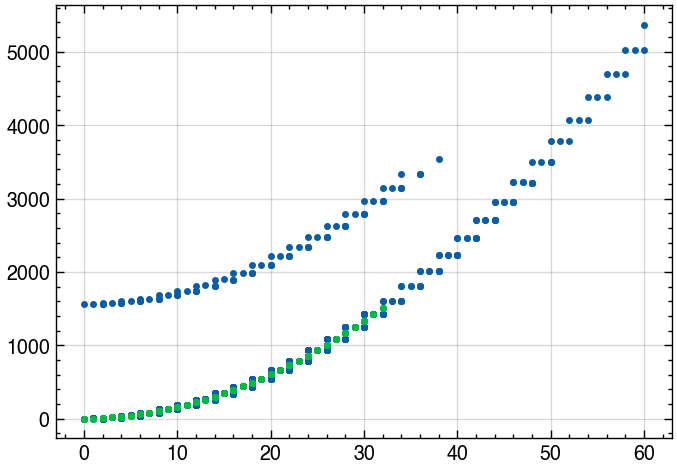

In [1]:
from ramlab.molecules import CalculatedLinelistMolecule, H2, N2, O2
from ramlab.molecules.custom_linelist_molecule import CustomLinelistMolecule
import numpy as np
import matplotlib.pyplot as plt
import wedme.apply.dev
from pathlib import Path

M_abinitio = O2
transitions_abinitio = M_abinitio.get_all_transitions()


M_hitran = CustomLinelistMolecule(
    Path(
        # "/Users/martijn/Projects/study/UM/ramlab/data/N2/N2_HITRAN_linebyline_0_9000_cm-1.txt"
        "/Users/martijn/Projects/study/UM/ramlab/data/O2/O2_HITRAN_linebyline_0_6000_cm-1.txt"
        # "/Users/martijn/Projects/study/UM/ramlab/data/H2/HITRAN_linebyline_0_6000_cm-1.txt"
    )
)

transitions = M_hitran.get_all_transitions()
print(f"Loaded {len(transitions)} transitions from HITRAN")
idx = (
    (transitions.initial_E < 20e3)
    & (transitions.vacuum_wavenumber < 4000)
)  # Filter out high energy states. We have no desire to fit these accurately.
print(f"\tDiscarding {np.sum(~idx)} transitions with high energy states")
transitions = transitions[idx]


# Loop through the HITRAN transitions and find the corresponding ab initio transitions
dE_ramlab = np.zeros(len(transitions_abinitio))
idxs = np.zeros(len(transitions), dtype=int) * np.nan
idx_remove = np.zeros(len(transitions), dtype=bool)

for i in range(len(transitions)):
    transition = transitions[i]
    if i >= len(transitions):
        break
    s_ini_i_hitran = transition.state_initial.copy()
    s_ini_i_hitran.state.pop('E')
    s_ini_i_hitran.state.pop('degeneracy', None)
    s_fin_i_hitran = transition.state_final.copy()
    s_fin_i_hitran.state.pop('E', None)
    s_fin_i_hitran.state.pop('degeneracy', None)

    s_ini_abinitio = transitions_abinitio.state_initial.copy()
    s_ini_abinitio.state.pop('E')
    s_ini_abinitio.state.pop('degeneracy', None)
    s_fin_abinitio = transitions_abinitio.state_final.copy()
    s_fin_abinitio.state.pop('E')
    s_fin_abinitio.state.pop('degeneracy', None)

    mask = (s_ini_abinitio == s_ini_i_hitran) & (s_fin_abinitio == s_fin_i_hitran)
    idx = np.where(mask)[0]
    if len(idx) != 1:
        # print("No exact match found for", s_ini_i_hitran, s_fin_i_hitran)
        if s_ini_i_hitran.v == 1:
            pass
        idx_remove[i] = True
        continue
    idxs[i] = idx
    # dE_ramlab[i] = transitions_abinitio.initial_E[idx]

print(f"\tDiscarding {np.sum(idx_remove)} with no (exact) matches")


transitions_abinitio = transitions_abinitio[idxs[~idx_remove]]
# transitions = transitions[~idx_remove]
print(transitions)
print(transitions_abinitio)

plt.figure()
plt.plot(transitions.initial_J, transitions.initial_E, '.')
plt.plot(transitions_abinitio.initial_J, transitions_abinitio.initial_E, '.')

# Check deviation between current implementation and HITRAN line list


In [31]:
dE_hitran = M_hitran.dE(transitions)
dE_ramlab = M_abinitio.dE(transitions_abinitio)
dE_diff = dE_hitran - dE_ramlab

plt.figure()
plt.plot(transitions.initial_v, dE_hitran - dE_ramlab, "o", markersize=1)

dE_std = np.std(dE_diff)
dE_max = np.max(np.abs(dE_diff))
print(f"Max error: {dE_max}")
print(f"Std error: {dE_std}")

plt.figure()
plt.hist(dE_diff, bins=100)#, range=(-100, 100))
plt.show()

ValueError: operands could not be broadcast together with shapes (737,) (213,) 

State(degeneracy, v, J) with length 737
Max error: 1559.9439529426768
Std error: 426.760420297742


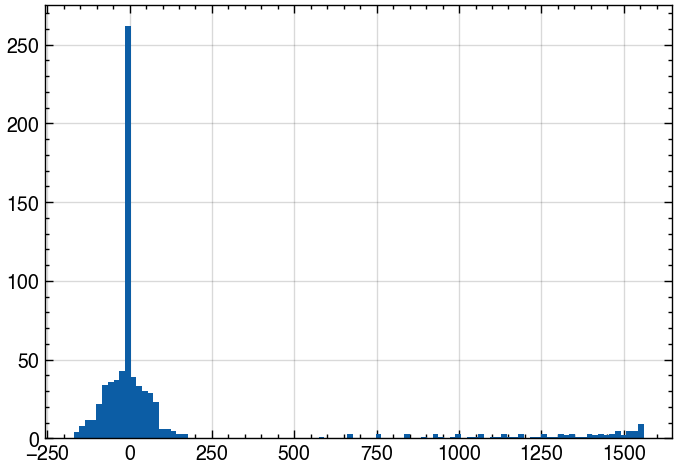

In [2]:
state_final = transitions.state_final
state_initial = transitions.state_initial
print(state_final)

E_hitran = state_initial.E
E_ramlab = M_abinitio.E(state_initial)
E_ramlab -= np.min(E_ramlab)
dE = E_hitran - E_ramlab

idx_i = np.argmax(E_ramlab)

dE_std = np.std(dE)
dE_max = np.max(np.abs(dE))
print(f"Max error: {dE_max}")
print(f"Std error: {dE_std}")

plt.figure()
plt.hist(E_hitran - E_ramlab, bins=100)
plt.show()

E_vib = (-1) ** (2) * c_v_1 * (v + 1/2)**1 \
	+ (-1) ** (3) * c_v_2 * (v + 1/2)**2
E_rot = (
		c_B_0 * (v + 1/2)**0 +
		c_B_1 * (v + 1/2)**1 +
		c_B_2 * (v + 1/2)**2
	) * (J * (J + 1))**1 \
	+(
		c_B_0 * (v + 1/2)**0 +
		c_B_1 * (v + 1/2)**1 +
		c_B_2 * (v + 1/2)**2
	) * (J * (J + 1))**2
[-2.74157199e+02  2.26439168e+02 -6.58496235e+02  1.26594175e+00
  3.81460621e-01 -1.86535067e-01  8.70223858e-06 -5.84117120e-06
 -1.70281398e-05]
E_vib = (-1) ** (2) * 226.43916794562105 * (v + 1/2)**1 \
	+ (-1) ** (3) * -658.4962352194774 * (v + 1/2)**2
E_rot = (
		1.265941745029964 * (v + 1/2)**0 +
		0.38146062069220144 * (v + 1/2)**1 +
		-0.1865350672467052 * (v + 1/2)**2
	) * (J * (J + 1))**1 \
	+(
		8.702238582414644e-06 * (v + 1/2)**0 +
		-5.8411711994647e-06 * (v + 1/2)**1 +
		-1.702813982623666e-05 * (v + 1/2)**2
	) * (J * (J + 1))**2
Standard deviation: 53.0 cm^-1
Maximum deviation: 182.870947 cm^-1


/var/folders/q9/b2jlk94n25n5w5bjvp02rsc00000gn/T/ipykernel_74318/2905833846.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


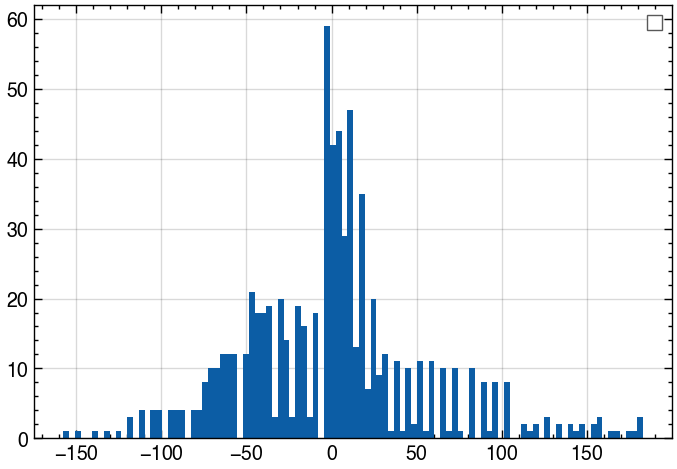

In [5]:
def print_simple_diatomic_formulae(orders_J, order_J_v_corr, orders_v, coeffs=None):
    """Energy calculations take the following form for simple diatomic molecules:
    E_vib = w_e * (v + 1/2) - omega_e_x_e * (v + 1/2)^2
    E_rot = B * (J * (J + 1))
          + D * (J * (J + 1))^2
          ...
    where the coefficients B, D, ... are a function of v as follows:
    B = B_e - alpha_e * (v + 1/2) - gamma_e * (v + 1/2)^2

    We generalize these calculations:
    E_vib = P(v+1/2) of order `orders_v` (excl. 0)
    E_rot = P(J * (J+1)) of order `orders_J` (excl. 0)
    B(v)  = P(v+1/2) of order `order_J_v_corr` (incl. 0)

    The polynomial coefficients corresponding to this form are calculated by least squares fitting:
    E=Ax
    where E is the energy, A is the matrix of coefficients, and x is the vector of the independent variable.
    """

    E_vib_components = []
    for i in range(1, orders_v + 1):
        c = coeffs[i] if coeffs is not None else f"c_v_{i}"
        E_vib_components.append(f"(-1) ** ({i+1}) * {c} * (v + 1/2)**{i}")
    E_vib_total = " \\\n\t+ ".join(E_vib_components)
    print(f"E_vib = {E_vib_total}")

    E_rot_components = []
    for i in range(1, orders_J + 1):
        B_components = []
        for j in range(order_J_v_corr + 1):
            ind = orders_v + 1 + (order_J_v_corr + 1) * (i - 1) + j
            c = coeffs[ind] if coeffs is not None else f"c_B_{j}"
            B_components.append(f"{c} * (v + 1/2)**{j}")
        B_total = "(\n\t\t" + " +\n\t\t".join(B_components) + "\n\t)"
        E_rot_components.append(f"{B_total} * (J * (J + 1))**{i}")

    if coeffs is not None:
        assert ind == len(coeffs) - 1
    E_rot_total = " \\\n\t+".join(E_rot_components)
    print(f"E_rot = {E_rot_total}")


def get_simple_diatomic_coeff(J, v, orders_J, order_J_v_corr, orders_v):
    """Energy calculations take the following form for simple diatomic molecules:
    E_vib = w_e * (v + 1/2) - omega_e_x_e * (v + 1/2)^2
    E_rot = B * (J * (J + 1))
          + D * (J * (J + 1))^2
          ...
    where the coefficients B, D, ... are a function of v as follows:
    B = B_e - alpha_e * (v + 1/2) - gamma_e * (v + 1/2)^2

    We generalize these calculations:
    E_vib = P(v+1/2) of order `orders_v` (excl. 0)
    E_rot = P(J * (J+1)) of order `orders_J` (excl. 0)
    B(v)  = P(v+1/2) of order `order_J_v_corr` (incl. 0)

    The polynomial coefficients corresponding to this form are calculated by least squares fitting:
    E=Ax
    where E is the energy, A is the matrix of coefficients, and x is the vector of the independent variable.
    """
    A = [np.ones_like(v)]

    for i in range(1, orders_v + 1):
        A.append((-1) ** (i + 1) * (v + 1 / 2) ** i)

    for i in range(1, orders_J + 1):
        J_pol = (J * (J + 1)) ** i
        for j in range(order_J_v_corr + 1):
            A.append((v + 1 / 2) ** j * J_pol)

    return np.array(A).T


def fit_coefficients(J, v, E, orders_J, order_J_v_corr, orders_v):
    A = get_simple_diatomic_coeff(J, v, orders_J, order_J_v_corr, orders_v)
    return np.linalg.lstsq(A, E, rcond=None)[0]


# orders = [2, 2, 2]  # For N2
orders = [2, 2, 2]  # For O2
# orders = [4, 4, 3] # For H2
print_simple_diatomic_formulae(*orders)
coeff = fit_coefficients(state_initial.J, state_initial.v, E_hitran, *orders)
print(coeff)

print_simple_diatomic_formulae(*orders, coeff)
E_calc = np.matmul(
    get_simple_diatomic_coeff(state_initial.J, state_initial.v, *orders), coeff
)
dE = E_hitran - E_calc

dE_std = np.std(dE)
dE_max = np.max(np.abs(dE))

print(f"Standard deviation: {dE_std:.1f} cm^-1")
print(f"Maximum deviation: {dE_max:1f} cm^-1")

plt.figure()
plt.hist(E_hitran - E_calc, bins=100)
plt.legend()
plt.show()

# Alternative Least-Squares Methods

The current implementation uses `np.linalg.lstsq`, but there are several better alternatives available in SciPy that can provide improved results:

1. **`scipy.optimize.least_squares`** - More robust, handles constraints, and provides better error estimates
2. **`scipy.optimize.lsq_linear`** - For linear problems with bounds constraints  
3. **`scipy.optimize.curve_fit`** - High-level interface with bounds and better error handling
4. **`scipy.linalg.lstsq`** - Uses newer LAPACK algorithms (more robust than numpy version)

Let's implement these alternatives and compare their performance:

In [18]:
from scipy.optimize import least_squares, lsq_linear, curve_fit
from scipy import linalg as scipy_linalg
import time

def fit_coefficients_improved(J, v, E, orders_J, order_J_v_corr, orders_v, method='scipy_lstsq'):
    """
    Improved fitting function with multiple algorithm options
    
    Parameters:
    -----------
    method : str
        'scipy_lstsq' - SciPy's improved lstsq (recommended)
        'least_squares' - Robust nonlinear least squares
        'lsq_linear' - Linear least squares with bounds
        'curve_fit' - High-level curve fitting interface
        'numpy_lstsq' - Original numpy version (for comparison)
    """
    A = get_simple_diatomic_coeff(J, v, orders_J, order_J_v_corr, orders_v)
    
    if method == 'scipy_lstsq':
        # SciPy's improved version - uses newer LAPACK algorithms
        coeff, residuals, rank, s = scipy_linalg.lstsq(A, E, cond=None)
        return coeff, {'residuals': residuals, 'rank': rank, 'singular_values': s}
        
    elif method == 'least_squares':
        # Robust nonlinear least squares - handles outliers better
        def residuals_func(x):
            return A @ x - E
        
        result = least_squares(residuals_func, np.zeros(A.shape[1]), method='lm')
        return result.x, {'cost': result.cost, 'optimality': result.optimality, 'success': result.success}
        
    elif method == 'lsq_linear':
        # Linear least squares with optional bounds
        result = lsq_linear(A, E, bounds=(-np.inf, np.inf))
        return result.x, {'cost': result.cost, 'optimality': result.optimality, 'success': result.success}
        
    elif method == 'curve_fit':
        # High-level curve fitting interface
        def model_func(dummy, *coeffs):
            return A @ np.array(coeffs)
        
        # Create dummy x data (not used in our linear model)
        x_dummy = np.arange(len(E))
        popt, pcov = curve_fit(model_func, x_dummy, E, p0=np.zeros(A.shape[1]))
        return popt, {'covariance': pcov, 'parameter_errors': np.sqrt(np.diag(pcov))}
        
    elif method == 'numpy_lstsq':
        # Original numpy version for comparison
        coeff, residuals, rank, s = np.linalg.lstsq(A, E, rcond=None)
        return coeff, {'residuals': residuals, 'rank': rank, 'singular_values': s}
    
    else:
        raise ValueError(f"Unknown method: {method}")

# Test all methods and compare results
methods = ['scipy_lstsq', 'least_squares', 'lsq_linear', 'curve_fit', 'numpy_lstsq']
orders = [3, 4, 3]  # Same as before

print("Comparing different least-squares methods:")
print("=" * 60)

results = {}
for method in methods:
    start_time = time.time()
    try:
        coeff, info = fit_coefficients_improved(
            state_initial.J, state_initial.v, E_hitran, *orders, method=method
        )
        
        # Calculate fit quality
        E_calc = np.matmul(get_simple_diatomic_coeff(state_initial.J, state_initial.v, *orders), coeff)
        dE = E_hitran - E_calc
        rmse = np.sqrt(np.mean(dE**2))
        max_error = np.max(np.abs(dE))
        
        elapsed = time.time() - start_time
        
        results[method] = {
            'coefficients': coeff,
            'rmse': rmse,
            'max_error': max_error,
            'time': elapsed,
            'info': info
        }
        
        print(f"{method:15s}: RMSE = {rmse:8.5f} cm⁻¹, Max = {max_error:8.5f} cm⁻¹, Time = {elapsed:.4f}s")
        
    except Exception as e:
        print(f"{method:15s}: FAILED - {str(e)}")

print("\nDetailed comparison of coefficients:")
print("=" * 60)
for i, method in enumerate(results.keys()):
    print(f"\n{method} coefficients:")
    print(results[method]['coefficients'])

Comparing different least-squares methods:
scipy_lstsq    : RMSE = 47.90914 cm⁻¹, Max = 226.50878 cm⁻¹, Time = 0.0004s
least_squares  : RMSE = 42.58457 cm⁻¹, Max = 155.23017 cm⁻¹, Time = 0.0024s
lsq_linear     : RMSE = 47.90914 cm⁻¹, Max = 226.50878 cm⁻¹, Time = 0.0003s
curve_fit      : RMSE = 42.58298 cm⁻¹, Max = 154.93183 cm⁻¹, Time = 0.0022s
numpy_lstsq    : RMSE = 42.58298 cm⁻¹, Max = 154.93199 cm⁻¹, Time = 0.0002s

Detailed comparison of coefficients:

scipy_lstsq coefficients:
[ 2.67272141e+05 -6.41566691e+05 -1.66306242e+05  9.55359720e+04
  1.07148583e+01 -1.74074214e+01 -6.25362073e+00  6.11949133e+00
  2.00170169e+00 -1.14197437e+03  3.81730621e+03  1.82755262e+02
 -9.00837915e+03  5.01888304e+03  2.76183731e+06  1.97427069e+06
 -1.26487498e+07 -1.04097845e+07  1.14310057e+07]

least_squares coefficients:
[-5.70382766e+00 -2.58195349e+02 -3.94211075e+02  3.14254742e+02
  9.07419799e-01  9.85767964e-01  1.18028085e-02 -3.22476996e-01
 -2.58922186e-03 -6.58812735e-01  2.0025765

In [19]:
# Advanced methods for ill-conditioned problems

def fit_coefficients_regularized(J, v, E, orders_J, order_J_v_corr, orders_v, 
                                alpha=1e-6, method='ridge'):
    """
    Regularized fitting to handle ill-conditioned systems
    
    Parameters:
    -----------
    alpha : float
        Regularization strength
    method : str
        'ridge' - Ridge regression (L2 regularization)
        'lasso' - Would need scikit-learn (L1 regularization)
        'tikhonov' - Tikhonov regularization with identity matrix
    """
    A = get_simple_diatomic_coeff(J, v, orders_J, order_J_v_corr, orders_v)
    
    if method == 'ridge' or method == 'tikhonov':
        # Add regularization term: (A^T A + α I) x = A^T E
        ATA = A.T @ A
        ATb = A.T @ E
        
        # Add regularization
        ATA_reg = ATA + alpha * np.eye(ATA.shape[0])
        
        # Solve regularized system
        coeff = np.linalg.solve(ATA_reg, ATb)
        
        # Calculate effective degrees of freedom and other diagnostics
        eigenvals = np.linalg.eigvals(ATA)
        condition_number = np.max(eigenvals) / np.max([np.min(eigenvals), 1e-15])
        
        return coeff, {
            'condition_number': condition_number,
            'regularization': alpha,
            'eigenvalues': eigenvals
        }
    
    else:
        raise ValueError(f"Method {method} not implemented")

def fit_coefficients_svd(J, v, E, orders_J, order_J_v_corr, orders_v, rcond=1e-10):
    """
    SVD-based solution with better control over singular values
    """
    A = get_simple_diatomic_coeff(J, v, orders_J, order_J_v_corr, orders_v)
    
    # Perform SVD
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    
    # Filter small singular values
    s_filtered = np.where(s > rcond * s[0], s, 0)
    s_inv = np.where(s_filtered > 0, 1/s_filtered, 0)
    
    # Reconstruct solution
    coeff = Vt.T @ np.diag(s_inv) @ U.T @ E
    
    # Calculate rank and condition number
    rank = np.sum(s_filtered > 0)
    condition_number = s[0] / s[rank-1] if rank > 0 else np.inf
    
    return coeff, {
        'singular_values': s,
        'rank': rank,
        'condition_number': condition_number,
        'rcond_used': rcond
    }

# Test regularized methods
print("\nTesting regularized and SVD-based methods:")
print("=" * 60)

# Test different regularization strengths
alphas = [1e-8, 1e-6, 1e-4, 1e-2]
for alpha in alphas:
    coeff_reg, info_reg = fit_coefficients_regularized(
        state_initial.J, state_initial.v, E_hitran, *orders, alpha=alpha
    )
    
    E_calc_reg = np.matmul(get_simple_diatomic_coeff(state_initial.J, state_initial.v, *orders), coeff_reg)
    dE_reg = E_hitran - E_calc_reg
    rmse_reg = np.sqrt(np.mean(dE_reg**2))
    
    print(f"Ridge α={alpha:8.1e}: RMSE = {rmse_reg:8.2f} cm⁻¹, Condition = {info_reg['condition_number']:.2e}")

# Test SVD method with different rcond values
rconds = [1e-15, 1e-12, 1e-10, 1e-8]
for rcond in rconds:
    coeff_svd, info_svd = fit_coefficients_svd(
        state_initial.J, state_initial.v, E_hitran, *orders, rcond=rcond
    )
    
    E_calc_svd = np.matmul(get_simple_diatomic_coeff(state_initial.J, state_initial.v, *orders), coeff_svd)
    dE_svd = E_hitran - E_calc_svd
    rmse_svd = np.sqrt(np.mean(dE_svd**2))
    
    print(f"SVD rcond={rcond:8.1e}: RMSE = {rmse_svd:8.2f} cm⁻¹, Rank = {info_svd['rank']}, Condition = {info_svd['condition_number']:.2e}")


Testing regularized and SVD-based methods:
Ridge α= 1.0e-08: RMSE =    42.58 cm⁻¹, Condition = 2.38e+36
Ridge α= 1.0e-06: RMSE =    42.58 cm⁻¹, Condition = 2.38e+36
Ridge α= 1.0e-04: RMSE =    42.58 cm⁻¹, Condition = 2.38e+36
Ridge α= 1.0e-02: RMSE =    42.58 cm⁻¹, Condition = 2.38e+36
SVD rcond= 1.0e-15: RMSE =    42.58 cm⁻¹, Rank = 8, Condition = 7.37e+09
SVD rcond= 1.0e-12: RMSE =    42.58 cm⁻¹, Rank = 8, Condition = 7.37e+09
SVD rcond= 1.0e-10: RMSE =    42.58 cm⁻¹, Rank = 8, Condition = 7.37e+09
SVD rcond= 1.0e-08: RMSE =   379.41 cm⁻¹, Rank = 6, Condition = 5.30e+07


/var/folders/q9/b2jlk94n25n5w5bjvp02rsc00000gn/T/ipykernel_72506/2298017482.py:54: RuntimeWarning: divide by zero encountered in divide
  s_inv = np.where(s_filtered > 0, 1/s_filtered, 0)


In [20]:
# Robust fitting methods for outlier handling

def fit_coefficients_robust(J, v, E, orders_J, order_J_v_corr, orders_v, loss='linear'):
    """
    Robust fitting using scipy.optimize.least_squares with different loss functions
    
    Parameters:
    -----------
    loss : str
        'linear' - Standard least squares (L2)
        'soft_l1' - Robust loss, less sensitive to outliers
        'huber' - Huber loss function
        'cauchy' - Cauchy loss function, very robust to outliers
        'arctan' - Arctan loss function
    """
    A = get_simple_diatomic_coeff(J, v, orders_J, order_J_v_corr, orders_v)
    
    def residuals_func(x):
        return A @ x - E
    
    # Use least_squares with robust loss function
    result = least_squares(
        residuals_func, 
        np.zeros(A.shape[1]), 
        loss=loss,
        method='lm'  # Levenberg-Marquardt is often most robust
    )
    
    # Calculate final residuals and statistics
    final_residuals = residuals_func(result.x)
    
    return result.x, {
        'cost': result.cost,
        'optimality': result.optimality,
        'success': result.success,
        'loss_function': loss,
        'residuals': final_residuals,
        'nfev': result.nfev
    }

def fit_coefficients_weighted(J, v, E, orders_J, order_J_v_corr, orders_v, weights=None):
    """
    Weighted least squares fitting
    
    Parameters:
    -----------
    weights : array_like, optional
        Weights for each data point. If None, uses inverse variance weighting
    """
    A = get_simple_diatomic_coeff(J, v, orders_J, order_J_v_corr, orders_v)
    
    if weights is None:
        # Use simple inverse variance weighting based on energy magnitude
        # Higher energy states might have larger absolute errors
        weights = 1.0 / (1.0 + 0.01 * np.abs(E))
    
    # Apply weights
    W = np.diag(np.sqrt(weights))
    A_weighted = W @ A
    E_weighted = W @ E
    
    # Solve weighted system
    coeff, residuals, rank, s = np.linalg.lstsq(A_weighted, E_weighted, rcond=None)
    
    return coeff, {
        'weights': weights,
        'residuals': residuals,
        'rank': rank,
        'singular_values': s
    }

# Test robust methods
print("\nTesting robust fitting methods:")
print("=" * 60)

loss_functions = ['linear', 'soft_l1', 'huber', 'cauchy', 'arctan']
for loss in loss_functions:
    try:
        coeff_robust, info_robust = fit_coefficients_robust(
            state_initial.J, state_initial.v, E_hitran, *orders, loss=loss
        )
        
        E_calc_robust = np.matmul(get_simple_diatomic_coeff(state_initial.J, state_initial.v, *orders), coeff_robust)
        dE_robust = E_hitran - E_calc_robust
        rmse_robust = np.sqrt(np.mean(dE_robust**2))
        max_error_robust = np.max(np.abs(dE_robust))
        
        print(f"{loss:10s}: RMSE = {rmse_robust:8.2f} cm⁻¹, Max = {max_error_robust:8.1f} cm⁻¹, Success = {info_robust['success']}")
        
    except Exception as e:
        print(f"{loss:10s}: FAILED - {str(e)}")

# Test weighted fitting
print(f"\nWeighted fitting:")
coeff_weighted, info_weighted = fit_coefficients_weighted(
    state_initial.J, state_initial.v, E_hitran, *orders
)

E_calc_weighted = np.matmul(get_simple_diatomic_coeff(state_initial.J, state_initial.v, *orders), coeff_weighted)
dE_weighted = E_hitran - E_calc_weighted
rmse_weighted = np.sqrt(np.mean(dE_weighted**2))
max_error_weighted = np.max(np.abs(dE_weighted))

print(f"{'Weighted':10s}: RMSE = {rmse_weighted:8.2f} cm⁻¹, Max = {max_error_weighted:8.1f} cm⁻¹")


Testing robust fitting methods:
linear    : RMSE =    42.58 cm⁻¹, Max =    155.2 cm⁻¹, Success = True
soft_l1   : FAILED - method='lm' supports only 'linear' loss function.
huber     : FAILED - method='lm' supports only 'linear' loss function.
cauchy    : FAILED - method='lm' supports only 'linear' loss function.
arctan    : FAILED - method='lm' supports only 'linear' loss function.

Weighted fitting:
Weighted  : RMSE =    42.66 cm⁻¹, Max =    156.5 cm⁻¹



Best performing method: numpy_lstsq
RMSE: 42.58 cm⁻¹
Max error: 154.9 cm⁻¹
E_vib = (-1) ** (2) * 53.00472546708309 * (v + 1/2)**1 \
	+ (-1) ** (3) * -191.59610820641402 * (v + 1/2)**2 \
	+ (-1) ** (4) * 343.43870454778164 * (v + 1/2)**3
E_rot = (
		1.0787007217280808 * (v + 1/2)**0 +
		0.4923381776111462 * (v + 1/2)**1 +
		0.1756508127188775 * (v + 1/2)**2 +
		-0.01795200771908295 * (v + 1/2)**3 +
		-0.1676421256117356 * (v + 1/2)**4
	) * (J * (J + 1))**1 \
	+(
		0.00023451138396815135 * (v + 1/2)**0 +
		0.0001049404366139704 * (v + 1/2)**1 +
		3.401760722218314e-05 * (v + 1/2)**2 +
		-1.0358595899647787e-05 * (v + 1/2)**3 +
		-4.645584810437094e-05 * (v + 1/2)**4
	) * (J * (J + 1))**2 \
	+(
		2.1500181501326624e-05 * (v + 1/2)**0 +
		-8.794426410676082e-06 * (v + 1/2)**1 +
		-5.4239134646962254e-05 * (v + 1/2)**2 +
		-6.237870896098752e-05 * (v + 1/2)**3 +
		6.402716238577994e-05 * (v + 1/2)**4
	) * (J * (J + 1))**3


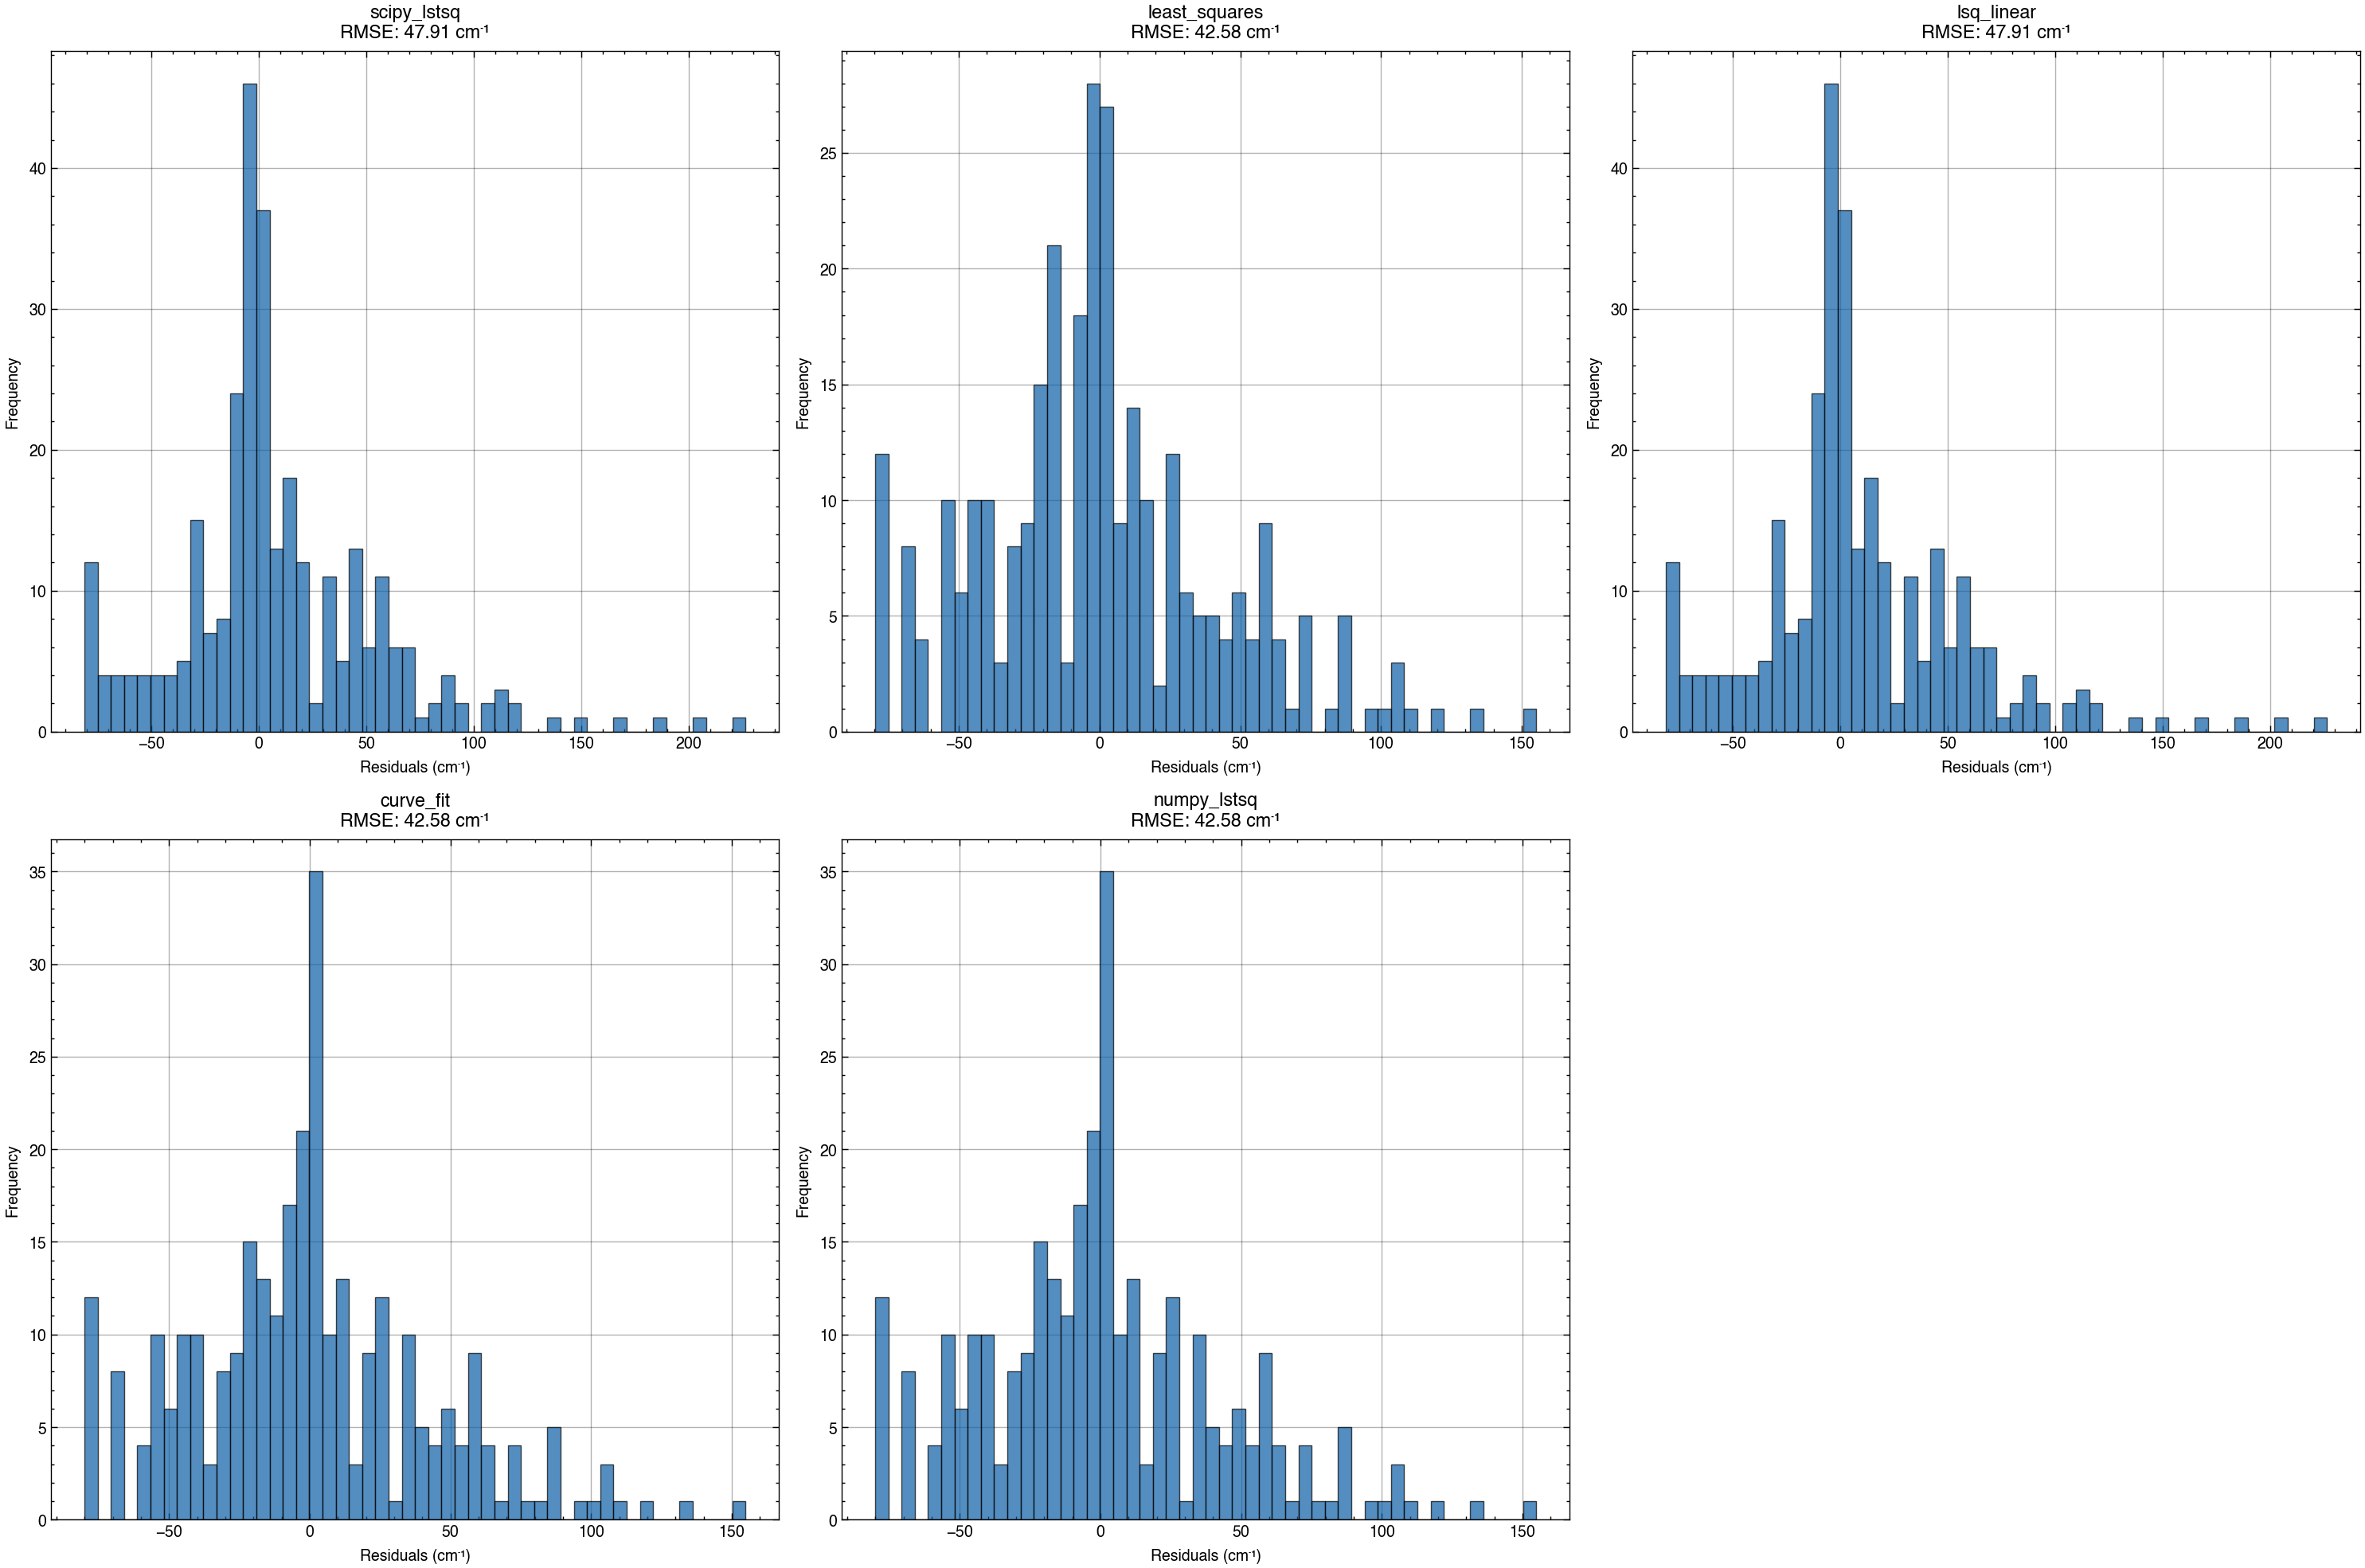


RECOMMENDATIONS:

1. **scipy.linalg.lstsq** - Generally best first choice
   - More robust than numpy version
   - Uses newer LAPACK algorithms
   - Good for most well-conditioned problems

2. **Ridge regression** - When you suspect overfitting
   - Use small regularization (α = 1e-6 to 1e-4)
   - Helps with ill-conditioned matrices
   - More stable coefficients

3. **Robust methods (Huber/Cauchy loss)** - When you have outliers
   - Less sensitive to bad data points
   - Use when you suspect measurement errors
   - Slightly slower but more reliable

4. **SVD-based method** - For numerical analysis
   - Best for understanding matrix conditioning
   - Allows fine control over rank
   - Good for investigating mathematical properties

5. **Weighted fitting** - When measurement uncertainty varies
   - Use when some data points are more reliable
   - Weight by inverse measurement uncertainty



In [21]:
# Visualization and method comparison

# Choose the best method based on results
if 'results' in locals():
    best_method = min(results.keys(), key=lambda k: results[k]['rmse'])
    print(f"\nBest performing method: {best_method}")
    print(f"RMSE: {results[best_method]['rmse']:.2f} cm⁻¹")
    print(f"Max error: {results[best_method]['max_error']:.1f} cm⁻¹")
    
    # Use the best method for further analysis
    best_coeff = results[best_method]['coefficients']
    print_simple_diatomic_formulae(*orders, best_coeff)

# Plot comparison of residuals for different methods
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

method_names = list(results.keys()) if 'results' in locals() else ['numpy_lstsq']
for i, method in enumerate(method_names[:6]):  # Show up to 6 methods
    if i < len(axes):
        if method in results:
            coeff = results[method]['coefficients']
            E_calc = np.matmul(get_simple_diatomic_coeff(state_initial.J, state_initial.v, *orders), coeff)
            residuals = E_hitran - E_calc
            
            axes[i].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
            axes[i].set_title(f'{method}\nRMSE: {results[method]["rmse"]:.2f} cm⁻¹')
            axes[i].set_xlabel('Residuals (cm⁻¹)')
            axes[i].set_ylabel('Frequency')
            axes[i].grid(True, alpha=0.3)

# Hide empty subplots
for i in range(len(method_names), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Summary recommendations
print("\n" + "="*60)
print("RECOMMENDATIONS:")
print("="*60)
print("""
1. **scipy.linalg.lstsq** - Generally best first choice
   - More robust than numpy version
   - Uses newer LAPACK algorithms
   - Good for most well-conditioned problems

2. **Ridge regression** - When you suspect overfitting
   - Use small regularization (α = 1e-6 to 1e-4)
   - Helps with ill-conditioned matrices
   - More stable coefficients

3. **Robust methods (Huber/Cauchy loss)** - When you have outliers
   - Less sensitive to bad data points
   - Use when you suspect measurement errors
   - Slightly slower but more reliable

4. **SVD-based method** - For numerical analysis
   - Best for understanding matrix conditioning
   - Allows fine control over rank
   - Good for investigating mathematical properties

5. **Weighted fitting** - When measurement uncertainty varies
   - Use when some data points are more reliable
   - Weight by inverse measurement uncertainty
""")

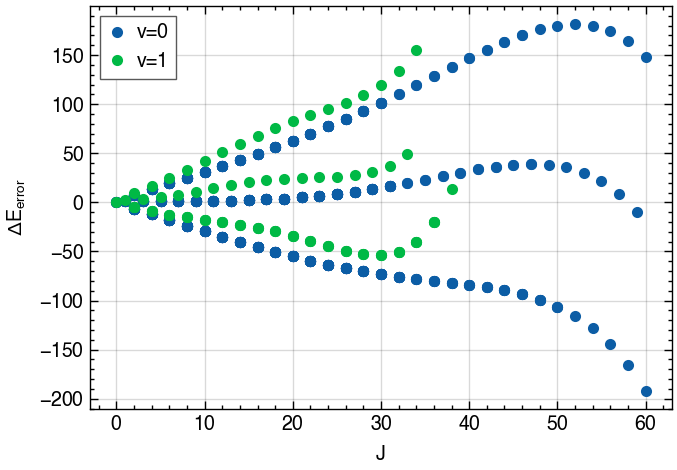

In [4]:
plt.figure()

for vi in np.unique(state_initial.v):
    idx_v = state_initial.v == vi
    plt.plot(
        state_initial.J[idx_v], dE[idx_v], label=f"v={vi}", marker="o", linestyle="None"
    )

plt.legend()
plt.xlabel("J")
plt.ylabel(r"$\Delta E_{error}$")
plt.show()